#1.0 Identificação e descrição do problema

## Titulo aqui

## Membros do grupo:
*   Edno Bezerra Nascimento Junior
*   Nicolle Rillary Santana Silva
*   Wagner Kauê Martins dos Santos

## Resumo:
O seguinte notebook foi desenvolvido como projeto avaliativo da matéria de Fundamentos da Inteligência Artificial.

O conjunto de códigos abaixo é responsável por realizar uma análise exploratória e o tratamento do conjunto de dados trabalhado, bem como a construção de um modelo de aprendizado de máquina para classificação de pacientes expostos a mordidas/picadas de animais possivelmente peçonhentos.

---

## Dataset utilizado:
O dataset [`silent_sting_triage_data.csv`](https://www.kaggle.com/datasets/jacopoferretti/emergency-triage-venomous-bites-dataset) apresenta dados simulados de atendimentos médicos ligados a pacientes envolvidos em acidentes de mordidas/picadas por animais possivelmente peçonhentos. O objetivo do dataset é classificar a origem da mordida/picada com base nos sintomas dos pacientes.

### Atributo-alvo:

`Bite_Source_Target` (String): classifica a fonte da mordida entre um conjunto de 4 valores possíveis: `Harmless_Insect` (inseto inofensivo), `Viper_Snake` (víbora), `Scorpion` (escorpião), `Black_Widow_Spider` (aranha viúva-negra).

### Atributos preditivos:
- `Patient_ID` (String): chave de identificação única para cada paciente;
- `Age` (Integer): idade do paciente;
- `Time_Since_Bite_Min` (Integer): tempo, em minutos, desde a mordida até o atendimento médico (relacionado à progressão dos sintomas);
- `Heart_Rate_BPM` (Integer): frequência cardíaca do paciente;
- `Blood_Pressure_Systolic` (Integer): pressão arterial sistólica (mm Hg);
- `Local_Swelling` (String): classificação da resposta física no local da mordida (None, Mild, Medium, Severe);
- `Muscle_Paralysis_Present` (Boolean): indicador binário (0 ou 1) ligado a efeitos de neurotoxinas.

### Tipo de tarefa desenvolvida:

Com base na estrutura do dataset — atributo-alvo categórico com 4 classes — o problema foi definido como uma tarefa de **classificação**, com o objetivo de identificar qual animal causou a mordida/picada com base nos sintomas e sinais vitais registrados do paciente.

### Objetivo:

O objetivo geral do trabalho foi desenvolver um modelo de classificação capaz de identificar a origem da mordida\picada, potencialmente venenosa, com base nos dados medicos de um paciente.

---
## Recursos Necessários (atualizar dps)

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/) (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`seaborn`](https://seaborn.pydata.org/) (versão 0.10.0 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas

Será utilizado também o conjuntos de dados disponibilizado junto com este *notebook*, que se encontra no diretório `datasets`, em formato de arquivo `.csv`.

# 2.0 Imports e carregamento do dataset


### 2.1 Imports das bibliotecas necessaria:

In [5]:
import numpy as np  #biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd #biblioteca usada para trabalhar com dataframes e análise de dados

# Geracao de graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Download do dataset
import kagglehub

# Pré-processamento e Validação
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Utilidade
import os
from logging import exception


print('Bibliotecas carregadas com sucesso')

Bibliotecas carregadas com sucesso


### 2.2 Carregamento do dataset


In [24]:
dataset_file_path = os.path.join('dataset', 'silent_sting_triage_data.parquet')

try:
    # tenta carregar o dataset local
    df = pd.read_parquet(dataset_file_path)
    print("Parquet encontrado, dataset carregado de:", dataset_file_path)

except FileNotFoundError:
    # se não encontrar, baixa do koggle
    print("Parquet não encontrado, baixando dataset do Kaggle...")

    path = kagglehub.dataset_download("jacopoferretti/emergency-triage-venomous-bites-dataset")
    csv_file_path = os.path.join(path, 'silent_sting_triage_data.csv')

    # previne que 'None' seja interpretado como NaN
    df = pd.read_csv(csv_file_path, sep=',', index_col=None, keep_default_na=False)

    # salva o arquivo
    os.makedirs(os.path.dirname(dataset_file_path), exist_ok=True)
    df.to_parquet(dataset_file_path, index=False)

    print("Download concluído, dataset salvo em:", dataset_file_path)

# Visualizando as 5 primeiras linhas
display(df.head())

Parquet encontrado, dataset carregado de: dataset/silent_sting_triage_data.parquet


,Patient_ID,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
0,PAT_000000,56,Male,153,126,121,Mild,0,0,Scorpion
1,PAT_000001,19,Female,124,150,138,Mild,0,0,Scorpion
2,PAT_000002,76,Male,196,99,100,Severe,0,1,Viper_Snake
3,PAT_000003,65,Male,143,139,144,Mild,0,0,Scorpion
4,PAT_000004,25,Female,195,87,98,Mild,0,0,Harmless_Insect


# 3.0 Compreensão dos dados

### 3.1 Dimensões e tipos das variáveis

In [25]:
print(f"Quantidade de registros: {df.shape[0]}")
print(f"Quantidade de atributos: {df.shape[1]}")
print("\nTipos de dados por coluna:")
print(df.dtypes)

Quantidade de registros: 1000000
Quantidade de atributos: 10

Tipos de dados por coluna:
Patient_ID                   object
Age                           int64
Gender                       object
Time_Since_Bite_Min           int64
Heart_Rate_BPM                int64
Blood_Pressure_Systolic       int64
Local_Swelling               object
Muscle_Paralysis_Present      int64
Blood_Coagulation_Failure     int64
Bite_Source_Target           object
dtype: object


O dataset possui aproximadamente 1 milhão de registros e 10 atributos (incluindo o alvo). As variáveis `Age`, `Time_Since_Bite_Min`, `Heart_Rate_BPM` e `Blood_Pressure_Systolic` são numéricas contínuas/discretas. `Gender`, `Local_Swelling` e `Bite_Source_Target` são categóricas (tipo `object`). `Muscle_Paralysis_Present` e `Blood_Coagulation_Failure` são binárias (0 ou 1), representando a presença ou ausência de um sintoma. `Patient_ID` é apenas um identificador único, sem valor preditivo.

### 3.2 Valores ausentes

In [26]:
print("Verificando valores ausentes por coluna:")
print(df.isnull().sum())

Verificando valores ausentes por coluna:
Patient_ID                   0
Age                          0
Gender                       0
Time_Since_Bite_Min          0
Heart_Rate_BPM               0
Blood_Pressure_Systolic      0
Local_Swelling               0
Muscle_Paralysis_Present     0
Blood_Coagulation_Failure    0
Bite_Source_Target           0
dtype: int64


Não há valores ausentes em nenhuma coluna do dataset. Isso indica que não será necessário nenhum tratamento de imputação (preenchimento) ou remoção de linhas por dados faltantes.

### 3.3 Duplicações e inconsistências

In [28]:
colunas_verificacao = ['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM',
                       'Blood_Pressure_Systolic','Local_Swelling',
                       'Muscle_Paralysis_Present','Blood_Coagulation_Failure']

# Duplicatas considerando os mesmos atributos preditivos (ignorando o alvo)
df_duplicatas = df[df.duplicated(subset=colunas_verificacao, keep=False)]

print(f"Total de registros duplicados (mesmos atributos preditivos): {len(df_duplicatas)}")

# Dentre as duplicatas, quantas têm rótulos (Bite_Source_Target) diferentes? (inconsistências reais)
df_inconsistentes = df_duplicatas[df_duplicatas.duplicated(subset=colunas_verificacao + ['Bite_Source_Target'], keep=False) == False]

print(f"Registros inconsistentes (mesmos atributos, rótulos diferentes): {len(df_inconsistentes)}")

Total de registros duplicados (mesmos atributos preditivos): 5639
Registros inconsistentes (mesmos atributos, rótulos diferentes): 8


Foram identificados registros duplicados considerando apenas os atributos preditivos. Uma parte dessas duplicatas apresenta o mesmo rótulo (redundância simples) e outra parte apresenta rótulos diferentes para os mesmos valores de entrada (inconsistência real, que pode confundir o modelo durante o treinamento). O tratamento desses casos será detalhado na seção de pré-processamento.

### 3.4 Distribuição do atributo-alvo

Distribuição das classes (contagem):
Bite_Source_Target
Harmless_Insect       399623
Viper_Snake           299928
Scorpion              150292
Black_Widow_Spider    150157
Name: count, dtype: int64

Distribuição das classes (proporção):
Bite_Source_Target
Harmless_Insect       0.40
Viper_Snake           0.30
Scorpion              0.15
Black_Widow_Spider    0.15
Name: proportion, dtype: float64


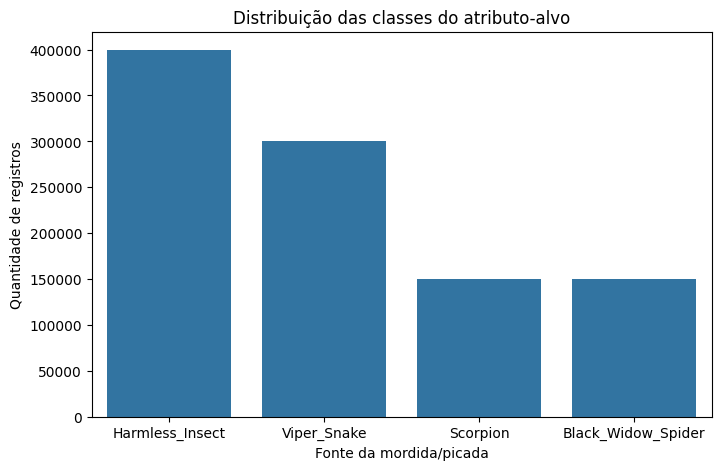

In [29]:
print("Distribuição das classes (contagem):")
print(df['Bite_Source_Target'].value_counts())

print("\nDistribuição das classes (proporção):")
print(df['Bite_Source_Target'].value_counts(normalize=True).round(3))

plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Bite_Source_Target', order=df['Bite_Source_Target'].value_counts().index)
plt.title('Distribuição das classes do atributo-alvo')
plt.xlabel('Fonte da mordida/picada')
plt.ylabel('Quantidade de registros')
plt.show()

O atributo-alvo apresenta desbalanceamento entre as classes: `Harmless_Insect` (40%) e `Viper_Snake` (30%) são majoritárias, enquanto `Scorpion` e `Black_Widow_Spider` (15% cada) são minoritárias. Esse desbalanceamento corresponde ao padrão de desbalanceamento esperado no mundo real, mas ele precisa ser considerado nas próximas etapas: será usada estratificação na separação treino/teste, e a avaliação dos modelos não deve se basear apenas em acurácia, mas também em métricas como precisão, revocação e F1-score por classe.

### 3.5 Distribuição das variáveis preditoras numéricas

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic
count,1000000.00,1000000.00,1000000.00,1000000.00
mean,44.47,124.38,105.01,117.28
std,23.10,66.37,27.06,24.50
min,5.00,10.00,40.00,35.00
25%,24.00,67.00,82.00,99.00
50%,44.00,124.00,102.00,118.00
75%,64.00,182.00,124.00,133.00
max,84.00,239.00,243.00,223.00


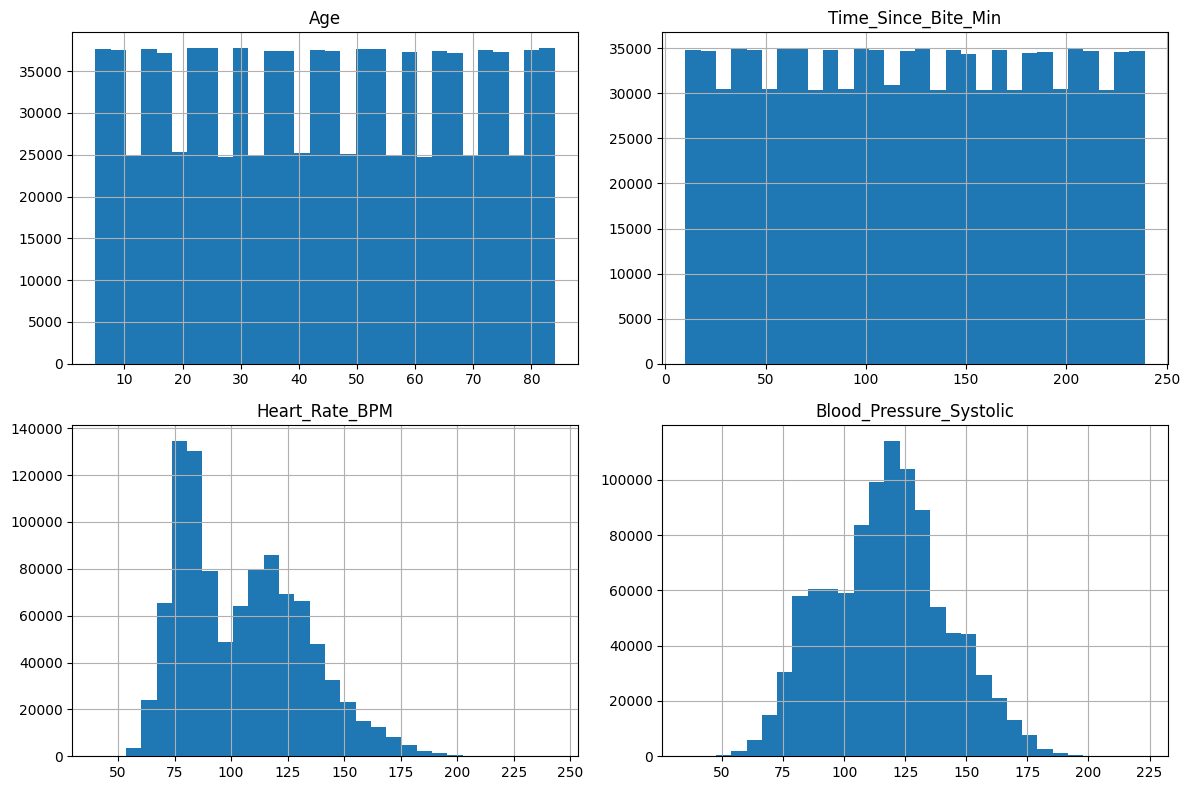

In [30]:
colunas_numericas_originais = ['Age', 'Time_Since_Bite_Min', 'Heart_Rate_BPM', 'Blood_Pressure_Systolic']

display(df[colunas_numericas_originais].describe().round(2))

df[colunas_numericas_originais].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

A idade dos pacientes varia entre valores compatíveis com a realidade (crianças a idosos), sem indícios de valores absurdos. O tempo desde a mordida (`Time_Since_Bite_Min`) apresenta ampla variação, o que é esperado dado que o atendimento pode ocorrer minutos ou horas após o incidente. A frequência cardíaca e a pressão sistólica apresentam distribuições consistentes com quadros de emergência médica, com alguns valores mais extremos que serão analisados na seção de outliers.

### 3.6 Distribuição das variáveis preditoras categóricas

In [31]:
print("Distribuição de Gender:")
print(df['Gender'].value_counts(normalize=True).round(3))

print("\nDistribuição de Local_Swelling:")
print(df['Local_Swelling'].value_counts(normalize=True).round(3))

print("\nDistribuição de Muscle_Paralysis_Present:")
print(df['Muscle_Paralysis_Present'].value_counts(normalize=True).round(3))

print("\nDistribuição de Blood_Coagulation_Failure:")
print(df['Blood_Coagulation_Failure'].value_counts(normalize=True).round(3))

Distribuição de Gender:
Gender
Male      0.49
Female    0.49
Other     0.02
Name: proportion, dtype: float64

Distribuição de Local_Swelling:
Local_Swelling
Mild      0.550
Severe    0.273
None      0.150
Medium    0.027
Name: proportion, dtype: float64

Distribuição de Muscle_Paralysis_Present:
Muscle_Paralysis_Present
0    0.857
1    0.143
Name: proportion, dtype: float64

Distribuição de Blood_Coagulation_Failure:
Blood_Coagulation_Failure
0    0.747
1    0.253
Name: proportion, dtype: float64


O dataset aprsenta um bom balanceamento de genero (`Gender`), os dados ligados ao `local_Swelling`, `Muscle_Paralysis_Present` e `Blood_Coagulation_Failure` apresentam um maior desbalanceamento, porém, essas distribuições estão dentro do esperado, uma vez que a maioria das mordidas\picadas tendem a gerar algum tipo de reação, mesmo que leve - o que é registrado pelo `local_Swelling` - e apenas uma menor taxa das mordidas\picadas gera efeitos de paralisia muscular ou falhas de coagulação que estão associados à toxinas mais severas - o que afeta o balanceamento dos atributos: `Muscle_Paralysis_Present` e `Blood_Coagulation_Failure`-.

### 3.7 Checagem de consistência de domínio

In [32]:
print("Idade mínima e máxima:", df['Age'].min(), "-", df['Age'].max())
print("Heart_Rate_BPM mínimo e máximo:", df['Heart_Rate_BPM'].min(), "-", df['Heart_Rate_BPM'].max())
print("Blood_Pressure_Systolic mínimo e máximo:", df['Blood_Pressure_Systolic'].min(), "-", df['Blood_Pressure_Systolic'].max())
print("Time_Since_Bite_Min mínimo e máximo:", df['Time_Since_Bite_Min'].min(), "-", df['Time_Since_Bite_Min'].max())

# Verifica valores fisiologicamente impossíveis (negativos ou zero onde não faz sentido)
inconsistencias_dominio = df[(df['Age'] <= 0) | (df['Heart_Rate_BPM'] <= 0) | (df['Blood_Pressure_Systolic'] <= 0)]
print(f"\nRegistros com valores fisiologicamente inválidos: {len(inconsistencias_dominio)}")

Idade mínima e máxima: 5 - 84
Heart_Rate_BPM mínimo e máximo: 40 - 243
Blood_Pressure_Systolic mínimo e máximo: 35 - 223
Time_Since_Bite_Min mínimo e máximo: 10 - 239

Registros com valores fisiologicamente inválidos: 0


O dataset não apresenta nenhum dado fisiologicamente impossivel, como valores negativos. Porém, apesar de conter dados esperados nos atributos de idade (`Age`) e tempo desde a mordida (`Time_Since_Bite_Min`), os valores de batimento cardiaco (`Heart_Rate_BPM`) e pressão sanguinea (`Blood_Pressure_Systolic`) apresentam valores mais extremos que podem indicar erros de medição ou quadro medicos severos, tais valores deverão ser analisados na seção de *outliers*

# 4.0 Analise exploratoria dos dados

---




# 5.0 Pre-processamento e separação dos dados

### 5.1 Limpeza de dados irrelevantes

A coluna `Patient_ID` não possui valor preditivo, logo a sua presença é dispensavel

In [41]:
df_Processamento = df.copy()

# Remove a coluna Patient_ID pois não tem valor preditivo
if 'Patient_ID' in df_Processamento.columns:
    df_Processamento = df_Processamento.drop('Patient_ID', axis=1)

display(df_Processamento.head())

,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
0,56,Male,153,126,121,Mild,0,0,Scorpion
1,19,Female,124,150,138,Mild,0,0,Scorpion
2,76,Male,196,99,100,Severe,0,1,Viper_Snake
3,65,Male,143,139,144,Mild,0,0,Scorpion
4,25,Female,195,87,98,Mild,0,0,Harmless_Insect


### 5.2 Valores nulos

In [35]:
# Verificando se há valores nulos
print("\nVerificando valores nulos:")
print(df_Processamento.isnull().sum())


Verificando valores nulos:
Age                          0
Gender                       0
Time_Since_Bite_Min          0
Heart_Rate_BPM               0
Blood_Pressure_Systolic      0
Local_Swelling               0
Muscle_Paralysis_Present     0
Blood_Coagulation_Failure    0
Bite_Source_Target           0
dtype: int64


Assim como verificado na etapa de compreensão dos dados, o dataset não apresenta valores nulos

### 5.3 Valores duplicados ou incosistentes

Verifica a existencia de valores duplicados desconsiderando a coluna de classificação `Bite_Source_Target`, o que inclui tanto entradas duplicadas (mesma classificação) e incosistentes (classificações diferentes)

In [43]:
# Busca valores duplicados com base nas colunas 'Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'
df_duplicates = df_Processamento[ df_Processamento.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores duplicados, exibe
if len(df_duplicates)>0:
    print(f"\n Numero de amostras duplicadas: {len(df_duplicates)}")
    print('\n Exemplos de amostras duplicadas:')
    display(df_duplicates)
else:
    print('Não existem valores duplicados')


 Numero de amostras duplicadas: 5639

 Exemplos de amostras duplicadas:


,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
506,43,Male,62,83,109,Mild,0,0,Harmless_Insect
751,65,Female,190,74,120,Mild,0,0,Harmless_Insect
975,10,Male,91,81,123,Mild,0,0,Harmless_Insect
1220,48,Male,139,87,124,Mild,0,0,Harmless_Insect
1493,50,Female,25,147,135,Mild,0,0,Scorpion
...,...,...,...,...,...,...,...,...,...
999039,30,Male,177,131,120,Mild,0,0,Scorpion
999255,38,Male,117,85,119,Mild,0,0,Harmless_Insect
999395,60,Male,34,88,116,Mild,0,0,Harmless_Insect
999615,67,Female,24,78,129,Mild,0,0,Harmless_Insect


Como existem entradas duplicadas, é necessario realizar um tratamento a fim de evitar problemas de enviesamento ou inconsistencias do modelo. Primeiro devemos diferenciar as entradas redundantes (mesma classficação) das entradas incosistentes (classificações distintas).

Fazendo uma nova busca por entradas duplicadas levando em consideração a coluna do atributo alvo `Bite_source_target` ou utilizando a função `drop_duplicates` é possivel encontrar e remover apenas os valores redundantes, nesse caso, foi escolhido remover os valores repetidos mantendo uma unica entrada de cada repetição.

In [44]:
# Remove os valores duplicados deixando apenas a primeira ocorrencia
df_Processamento = df_Processamento.drop_duplicates(keep = 'first')


# Novo teste de valores duplicados
# Captura valores inconsistentes (entradas duplicadas com classificações diferentes)
df_duplicates = df_Processamento[ df_Processamento.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores inconsistentes, exibe
if len(df_duplicates)>0:
    print(f'\nAmostras inconsistentes:{df_duplicates.shape[0]}')
    print('\nExemplos de amostras inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores inconsistentes')


Amostras inconsistentes:8

Exemplos de amostras inconsistentes:


,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target
209228,6,Female,12,80,110,Mild,0,0,Scorpion
219397,28,Female,62,82,132,Mild,0,0,Harmless_Insect
220381,6,Female,12,80,110,Mild,0,0,Harmless_Insect
487733,28,Female,136,96,117,Mild,0,0,Scorpion
505569,28,Female,136,96,117,Mild,0,0,Harmless_Insect
527697,14,Female,222,90,108,Mild,0,0,Scorpion
686822,14,Female,222,90,108,Mild,0,0,Harmless_Insect
875419,28,Female,62,82,132,Mild,0,0,Scorpion


A nova verificação de valores duplicados revelou a existencia de entradas incosistentes, ou seja, entradas duplicadas que possuem uma classificação distinta, essas entradas geram problemas de incosistencia do modelo e geralmente estão ligadas à casos especiais ou erros de medição. Como nenhum dos dados incosistentes é confiavel, o tratamento adotado foi remover todas as entradas inconsistentes.

Remove todos os valores inconsistentes e realiza um novo teste de duplicatas apenas para garantir que os dados foram totalmente tratados

In [45]:
# Remove todos os valores incosistentes
df_Processamento = df_Processamento.drop_duplicates(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'], keep = False)

# Ultimo teste de valores duplicados\incosistentes
df_duplicates = df_Processamento[ df_Processamento.duplicated(subset=['Age','Gender','Time_Since_Bite_Min','Heart_Rate_BPM','Blood_Pressure_Systolic','Local_Swelling','Muscle_Paralysis_Present','Blood_Coagulation_Failure'],keep=False)]

# Caso existam valores inconsistentes, exibe
if len(df_duplicates)>0:
    print('\nAmostras inconsistentes:')
    display(df_duplicates)
else:
    print('Não existem valores inconsistentes ou duplicados')

Não existem valores inconsistentes ou duplicados


### 5.4 Dados não numericos

Dados não numericos afetam a eficiencia do processo de treinamento do modelo, além disso, a maioria dos modelos não conseguem lidar com dados não numericos. Assim como observado na etapa de compreensão dos dados, certas colunas do dataset possuem entradas não numericas que devem ser tratadas

In [47]:
print(f"Quantidade de registros: {df_Processamento.shape[0]}")
print(f"Quantidade de atributos: {df_Processamento.shape[1]}")
print("\nTipos de dados por coluna:")
print(df_Processamento.dtypes)

Quantidade de registros: 997170
Quantidade de atributos: 9

Tipos de dados por coluna:
Age                           int64
Gender                       object
Time_Since_Bite_Min           int64
Heart_Rate_BPM                int64
Blood_Pressure_Systolic       int64
Local_Swelling               object
Muscle_Paralysis_Present      int64
Blood_Coagulation_Failure     int64
Bite_Source_Target           object
dtype: object


As colunas `Local_Swelling`, `Gender` e `Bite_Source_Target` possuem valores do tipo `Object` que devem ser tratados a fim de facilitar o processamento dos dados. Nesse caso, as entradas `Local_Swelling` e `Gender` serão convertidas para entradas bollean, com a adição de colunas extras, enquanto a entrada `Bite_Source_Target` será convertida pera uma entrada numerica

In [12]:
# Create a copy to avoid modifying the original dataframe in place unexpectedly if run multiple times
# Or, ensure columns are present before processing

# 1. Variáveis Categóricas Preditoras (One-Hot Encoding)
# Check if 'Gender' and 'Local_Swelling' columns exist before processing
if 'Gender' in df_Processamento.columns and 'Local_Swelling' in df_Processamento.columns:
    df_Processamento = pd.get_dummies(df_Processamento, columns=['Gender', 'Local_Swelling'], drop_first=True)
elif 'Gender' in df_Processamento.columns: # Handle cases where one might be missing but not the other
    df_Processamento = pd.get_dummies(df_Processamento, columns=['Gender'], drop_first=True)
elif 'Local_Swelling' in df_Processamento.columns:
    df_Processamento = pd.get_dummies(df_Processamento, columns=['Local_Swelling'], drop_first=True)

# 2. Variável Alvo (Label Encoding)
# Check if 'Bite_Source_Target' is still an object type before encoding
if 'Bite_Source_Target' in df_Processamento.columns and df_Processamento['Bite_Source_Target'].dtype == 'object':
    le = LabelEncoder()
    df_Processamento['Bite_Source_Target'] = le.fit_transform(df_Processamento['Bite_Source_Target'])

# Verificando como ficou o dataset após as transformações
display(df_Processamento.head())

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Bite_Source_Target,Gender_Male,Gender_Other,Local_Swelling_Mild,Local_Swelling_None,Local_Swelling_Severe
0,56,153,126,121,0,0,2,True,False,True,False,False
1,19,124,150,138,0,0,2,False,False,True,False,False
2,76,196,99,100,0,1,3,True,False,False,False,True
3,65,143,139,144,0,0,2,True,False,True,False,False
4,25,195,87,98,0,0,1,False,False,True,False,False


### 5.5 Separação de dados de treino e teste (20/80)


Agora que o tratamento inicial dos dados já foi realizado (remoção de duplicatas e conversão dos valores não numericos), o dataset inicial será separado em dois grupos distintos usando uma proporção de 20% para testes e 80% para treinamento.

Essa seperação será feita levando em conta a distribuição orginal das classes, visando manter essa mesma distribuição em ambas partes.

In [48]:
# Separando features (X) e target (y)
X = df_Processamento.drop('Bite_Source_Target', axis=1)
y = df_Processamento['Bite_Source_Target']

# Dividindo os dados em conjuntos de treino e teste (80/20) de forma estratificada
# A estratificação garante que a proporção de cada classe em 'y' seja a mesma nos conjuntos de treino e teste.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Tamanho do conjunto de treino (y_train): {y_train.shape}")
print(f"Tamanho do conjunto de teste (y_test): {y_test.shape}")

# Verificar a distribuição das classes nos conjuntos de treino e teste
print("\nDistribuição das classes em y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribuição das classes em y_test:")
print(y_test.value_counts(normalize=True))

Tamanho do conjunto de treino (X_train): (797736, 8)
Tamanho do conjunto de teste (X_test): (199434, 8)
Tamanho do conjunto de treino (y_train): (797736,)
Tamanho do conjunto de teste (y_test): (199434,)

Distribuição das classes em y_train:
Bite_Source_Target
Harmless_Insect       0.398682
Viper_Snake           0.300231
Scorpion              0.150633
Black_Widow_Spider    0.150455
Name: proportion, dtype: float64

Distribuição das classes em y_test:
Bite_Source_Target
Harmless_Insect       0.398683
Viper_Snake           0.300230
Scorpion              0.150631
Black_Widow_Spider    0.150456
Name: proportion, dtype: float64


### 5.6 Normalização

Modelos que utilizam algoritmos matematicos para realizar o processo de classificação, como o `K-Nearest Neighbors (KNN)` podem apresentar falhas serevas caso as colunas numericas aprsentem dimenções distintas, nesse caso as colunas com valores maiores acabam tendo um maior peso durante a classificação, a fim de evitar esse problema, foi realizada a normalização dos dados de treino e de testes

In [50]:
# apresenta as principais estatísticas da base de dados de treinamento
df_detalhes = X_train.describe()

display(df_detalhes.round(8))

,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000
mean,44.461193,124.387816,105.049305,117.303164,0.143346,0.253490
std,23.085763,66.364376,27.062013,24.529121,0.350425,0.435009
min,5.000000,10.000000,42.000000,39.000000,0.000000,0.000000
25%,24.000000,67.000000,82.000000,99.000000,0.000000,0.000000
50%,44.000000,124.000000,102.000000,118.000000,0.000000,0.000000
75%,64.000000,182.000000,124.000000,133.000000,0.000000,1.000000
max,84.000000,239.000000,243.000000,223.000000,1.000000,1.000000


In [51]:
# Inicializa o normalizador (Média 0 e Desvio Padrão 1)
scaler = StandardScaler()

# Lista das colunas numéricas que precisam de ajuste
colunas_numericas = ['Age', 'Time_Since_Bite_Min', 'Heart_Rate_BPM', 'Blood_Pressure_Systolic']

# Cria uma copia normalizada dos dados
X_train_Normalizado = X_train.copy()

# Normaliza as colunas numéricas
X_train_Normalizado[colunas_numericas] = scaler.fit_transform(X_train_Normalizado[colunas_numericas])

# Exibe os dados normalizados e as suas estatisticas
display(X_train_Normalizado.head())
print('\n')
display(X_train_Normalizado.describe().round(8))

,Age,Gender,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Local_Swelling,Muscle_Paralysis_Present,Blood_Coagulation_Failure
393316,-0.106611,Male,1.003735,0.441604,0.762231,Mild,0,0
852561,0.629774,Male,-1.271584,-0.740866,-0.053127,Mild,0,0
611780,-1.059580,Female,-0.216800,0.330748,-0.868485,Severe,0,1
191771,1.019625,Female,1.139350,-0.925627,-0.256967,Mild,0,0
412650,-1.449431,Male,1.169486,-1.184292,0.476855,Mild,0,0


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000,797736.000000
mean,0.000000,-0.000000,0.000000,-0.000000,0.143346,0.253490
std,1.000001,1.000001,1.000001,1.000001,0.350425,0.435009
min,-1.709331,-1.723634,-2.329810,-3.192255,0.000000,0.000000
25%,-0.886313,-0.864739,-0.851722,-0.746181,0.000000,0.000000
50%,-0.019977,-0.005844,-0.112678,0.028409,0.000000,0.000000
75%,0.846358,0.868120,0.700270,0.639927,0.000000,1.000000
max,1.712693,1.727015,5.097580,4.309038,1.000000,1.000000


In [16]:
# Cria uma copia normalizada dos dados de teste
X_test_Normalizado = X_test.copy()

# Aplica a normalização nas colunas numéricas do conjunto de teste
# IMPORTANTE: Usamos APENAS 'transform' com o scaler já ajustado em X_train
X_test_Normalizado[colunas_numericas] = scaler.transform(X_test_Normalizado[colunas_numericas])

# Exibe os dados normalizados e as suas estatísticas
print("X_test normalizado (primeiras 5 linhas):")
display(X_test_Normalizado.head())
print('\nEstatísticas descritivas de X_test normalizado:')
display(X_test_Normalizado.describe().round(8))

X_test normalizado (primeiras 5 linhas):


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure,Gender_Male,Gender_Other,Local_Swelling_Mild,Local_Swelling_None,Local_Swelling_Severe
539800,0.759724,-1.663361,-1.221244,0.232248,0,0,False,False,True,False,False
155569,0.456507,0.822915,0.478557,1.536821,1,0,False,False,False,True,False
915850,-1.666015,-0.337347,0.293796,-0.623878,0,1,False,False,False,False,True
139817,1.279526,1.651673,-0.814770,-0.053127,0,0,True,False,True,False,False
857484,0.976308,-1.377062,1.771883,1.740660,0,0,False,False,True,False,False



Estatísticas descritivas de X_test normalizado:


,Age,Time_Since_Bite_Min,Heart_Rate_BPM,Blood_Pressure_Systolic,Muscle_Paralysis_Present,Blood_Coagulation_Failure
count,199434.000000,199434.000000,199434.000000,199434.000000,199434.000000,199434.000000
mean,0.002105,-0.000279,0.000710,-0.002886,0.143286,0.253106
std,1.002363,1.000590,1.001158,0.998409,0.350365,0.434792
min,-1.709331,-1.723634,-2.403714,-3.355327,0.000000,0.000000
25%,-0.886313,-0.864739,-0.851722,-0.746181,0.000000,0.000000
50%,-0.019977,-0.005844,-0.112678,0.028409,0.000000,0.000000
75%,0.889675,0.868120,0.700270,0.639927,0.000000,1.000000
max,1.712693,1.727015,4.691106,3.656751,1.000000,1.000000


### 5.7 Analise de *outliers*

Utilizando uma representação grafica dos dados de treinamento é possivel analisar a distribuição numerica e analisar a presença de outliers



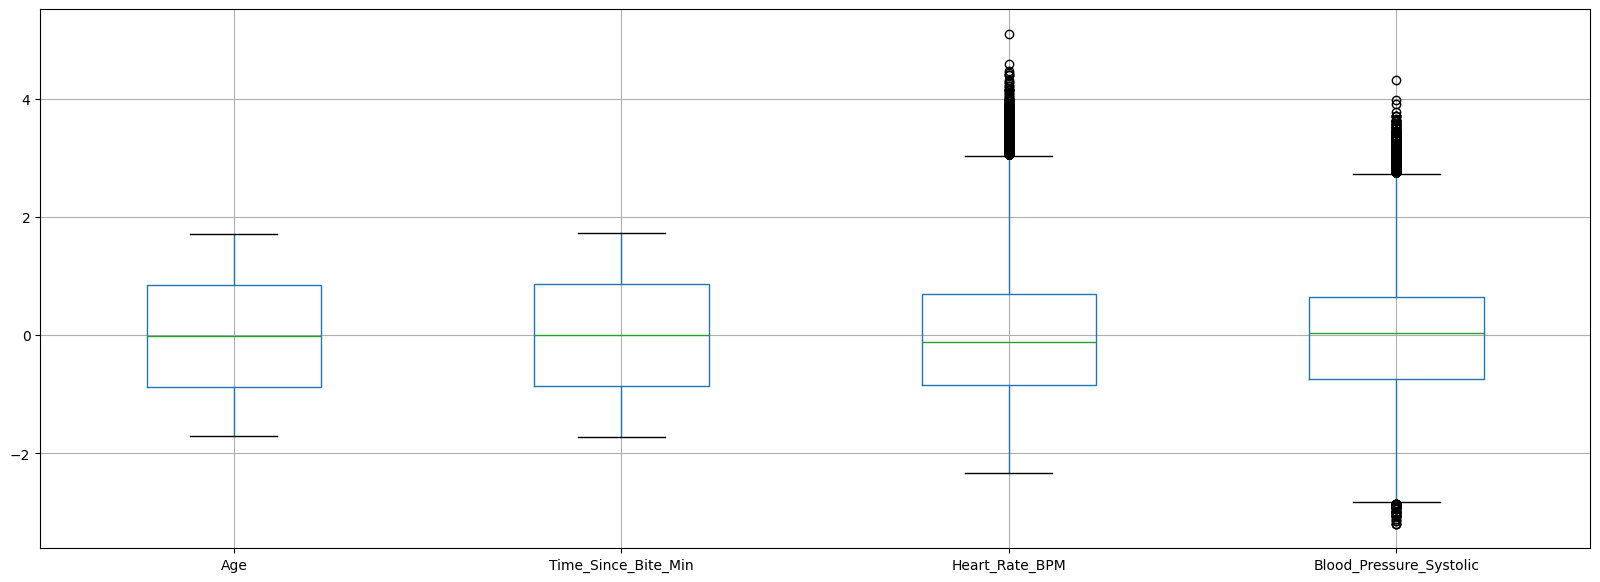

In [17]:
X_train_Normalizado[colunas_numericas].boxplot(figsize=(20,7))
plt.show()

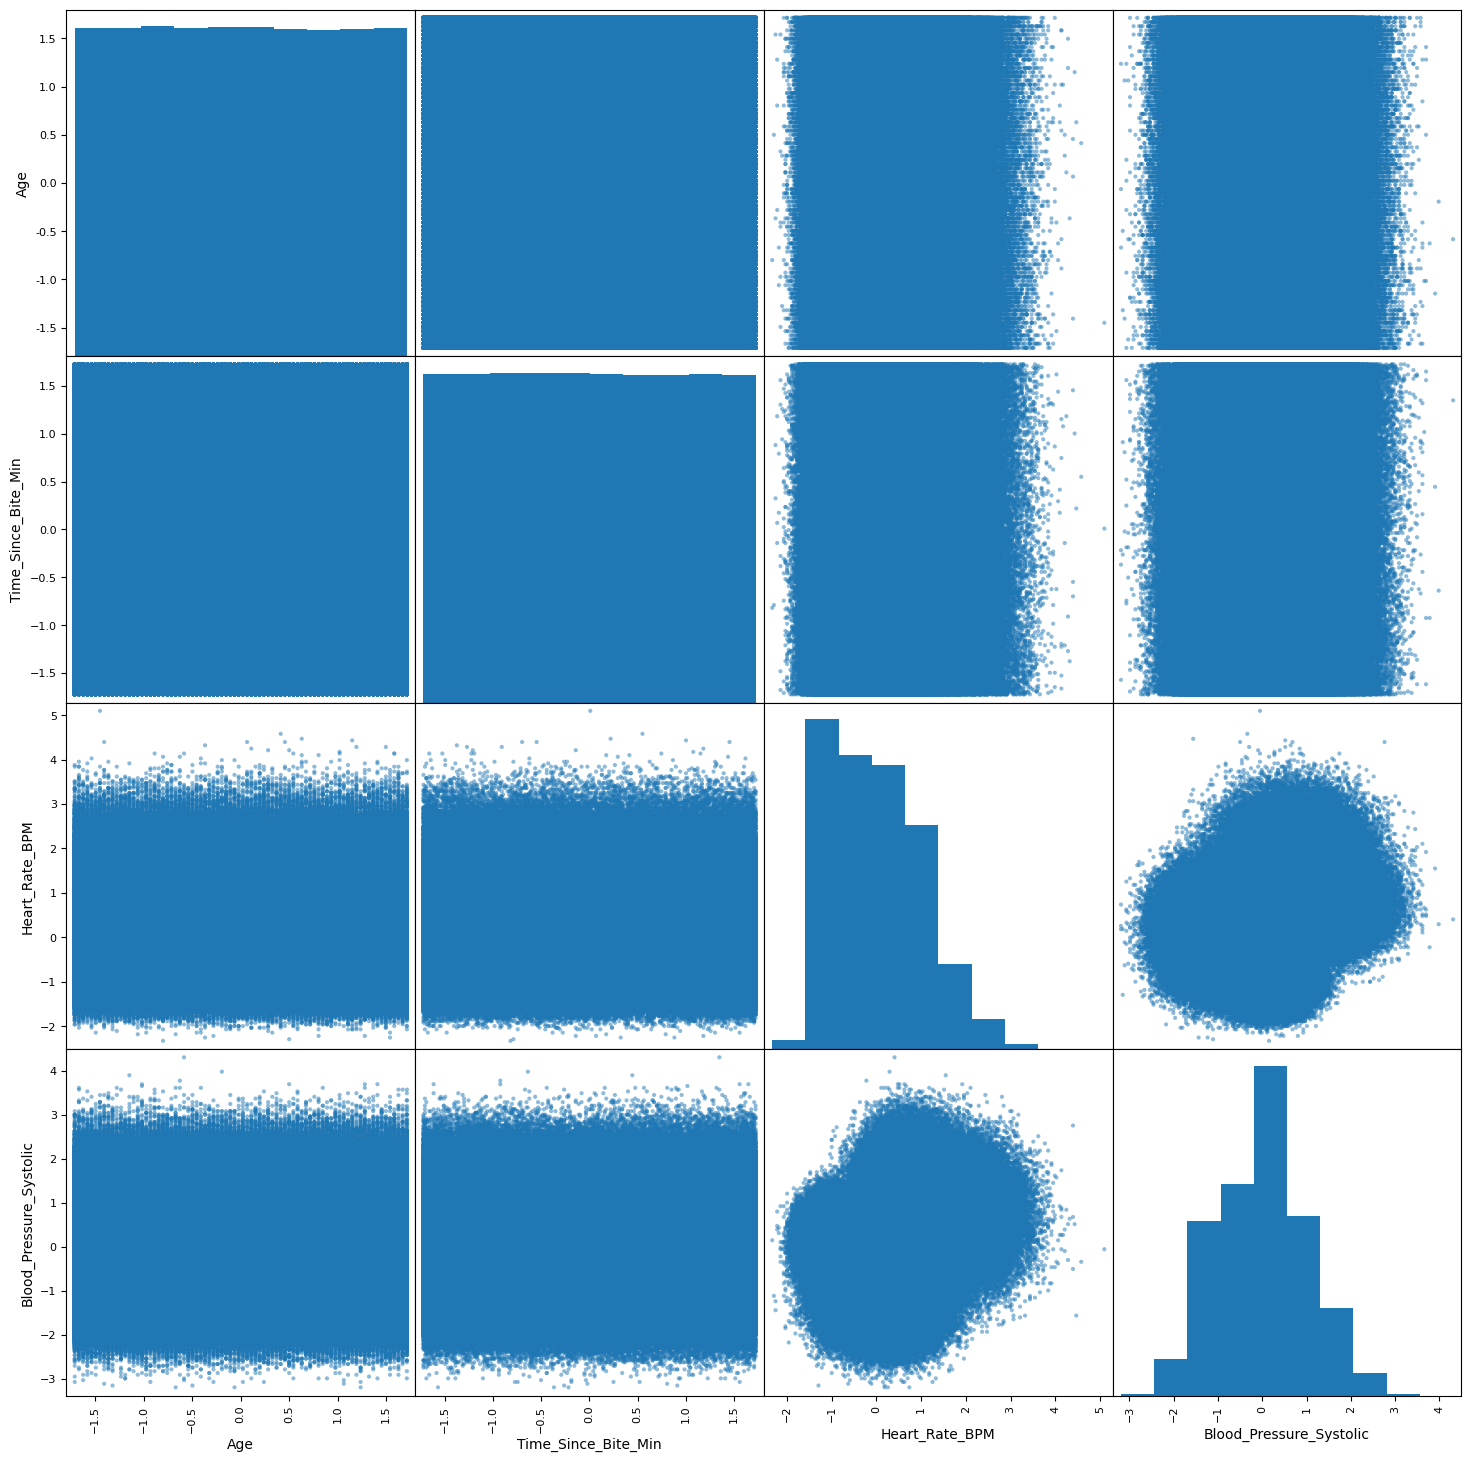

In [18]:
pd.plotting.scatter_matrix(X_train_Normalizado[colunas_numericas], figsize=(18,18))

plt.show()

A analise grafica dos dados numericos revela a presença de outliers nas colunas `Heart_rate_bpm` e `Blood_presure_sistolic`. Porém, tais outliers não parecem ligados à erros de medição e representam dados importante para o diagnostico de estado geral do paceiente. Taxas elevadas de batimentos cardiacos podem indicar problemas cardiacos ligados à efeitos de neurotoxinas por exemplo, logo esses dados não devem ser removidos

# 6.0 Treinamento dos modelos